# Vector Fields - Reactive Algorithms Pt 1.
## Sink/Source - Finding the Centre and circumnavigation - 3 approaches

### 1. But First, a little visualization

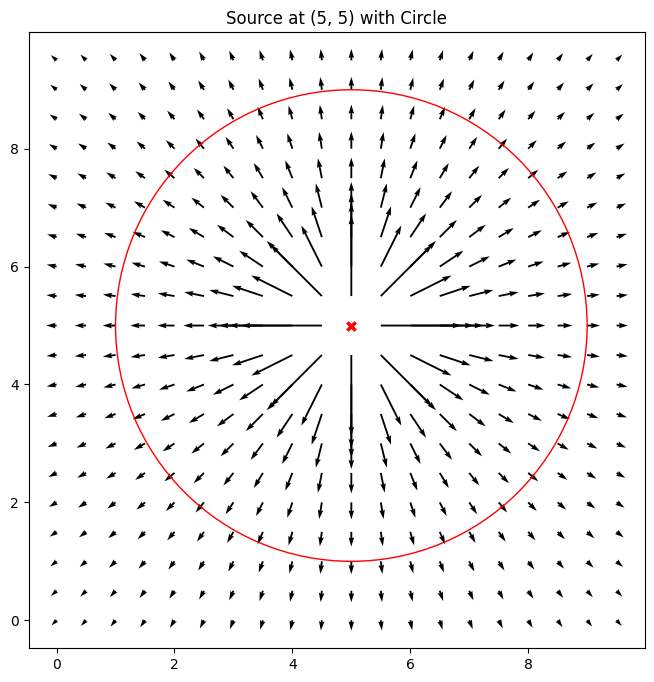

In [1]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt

# Create Meshgrid
x = np.arange(0, 10, 0.5)
y = np.arange(0, 10, 0.5)
X, Y = np.meshgrid(x, y)

# Source Location
x_source = 5
y_source = 5

# Centring over source
x_centre = X - x_source
y_centre = Y - y_source

# Radial Distance from Centre
r = np.sqrt(x_centre**2 + y_centre**2)

# Avoid division by zero at the center
r[r==0] = 1e-6

# Calculate the source vectors at each point
u = x_centre / r**2
v = y_centre / r**2

plt.figure(figsize=(8, 8))

# Quiver plot
plt.quiver(X, Y, u, v)

# Add source point
plt.scatter(x_source, y_source, color='red', marker='x', linewidths=2.5)

# Create circle
circle = plt.Circle((5,5), 4, color='red', fill=False)

# Add the circle to the plot
plt.gca().add_patch(circle)

# Set aspect ratio to be equal, so the circle looks circular
plt.gca().set_aspect('equal')

plt.title("Source at (5, 5) with Circle")
plt.show()


## Direction Follower Method - Find Source

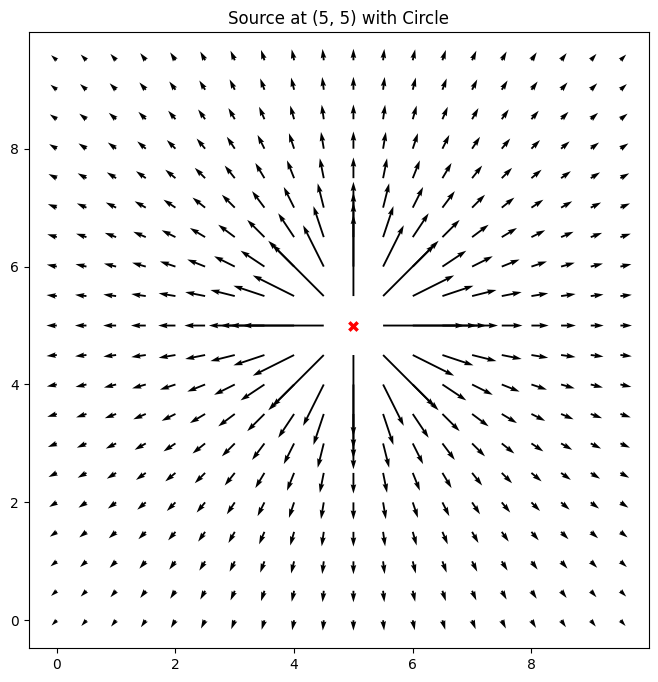

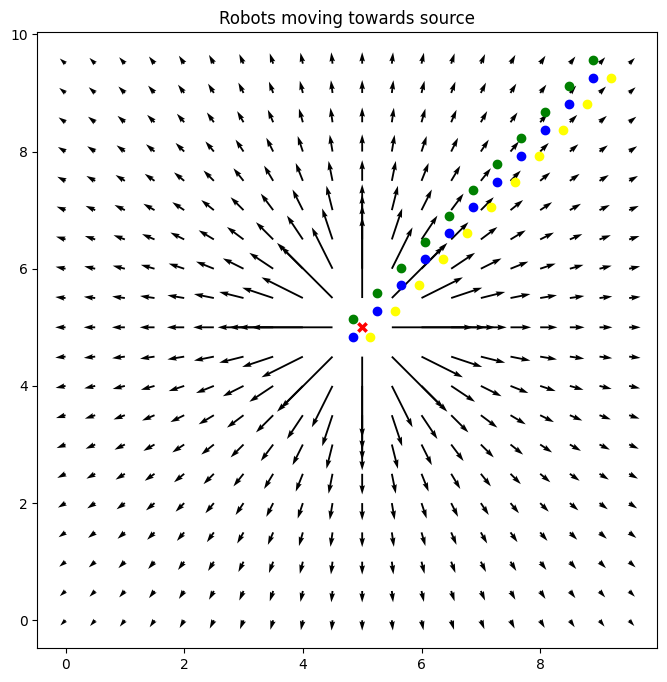

It took this many steps:  11


In [79]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, Eq, solve

# 1. Creating the Environment For Visualization

# Create Meshgrid
x = np.arange(0, 10, 0.5)
y = np.arange(0, 10, 0.5)
X, Y = np.meshgrid(x, y)

# Source Location
x_source = 5
y_source = 5

# Centring over source
x_centre = X - x_source
y_centre = Y - y_source

# Radial Distance from Centre
r = np.sqrt(x_centre**2 + y_centre**2)

# Avoid division by zero at the center
r[r==0] = 1e-6

# Calculate the source vectors at each point
u = x_centre / r**2
v = y_centre / r**2

# Create Visualization

plt.figure(figsize=(8,8))
plt.quiver(X,Y,u,v)
plt.scatter(x_source, y_source, color='red', marker='x', linewidths=2.5)
plt.title("Source at (5, 5) with Circle")
plt.show()


plt.figure(figsize=(8,8))
plt.quiver(X,Y,u,v)
plt.scatter(x_source, y_source, color='red', marker='x', linewidths=2.5)




# 2. Initializing the robot positions

x1 = 9.3
y1 = 9.7
x2 = x1 + 0.3
y2 = y1
x3 = x1
y3 = y1+ 0.3
pos1 = [x1,y1]
pos2 = [x2,y2]
pos3 = [x3,y3]
step_size = 0.6
steps =0

# 3. Algorithm to move towards source

for _ in range (1,20):
    # Vector Magnitude and Direction at Robot 1
    u_dist1 = pos1[0] - x_source
    v_dist1 = pos1[1] - y_source

    u1 = u_dist1/((u_dist1**2 + v_dist1**2))
    v1 = v_dist1/((u_dist1**2 + v_dist1**2))

    magnitude1 = (u1**2 + v1**2)**0.5
    angle1 = np.arctan2(-v1, -u1)

    # Vector Magnitude and Direction at Robot 2
    u_dist2 = pos2[0] - x_source
    v_dist2 = pos2[1] - y_source

    u2 = u_dist2/((u_dist2**2 + v_dist2**2))
    v2 = v_dist2/((u_dist2**2 + v_dist2**2))

    magnitude2 = (u2**2 + v2**2)**0.5
    angle2 = np.arctan2(-v2, -u2)

    # Vector Magnitude and Direction at Robot 3
    u_dist3 = pos3[0] - x_source
    v_dist3 = pos3[1] - y_source

    u3 = u_dist3/((u_dist3**2 + v_dist3**2))
    v3 = v_dist3/((u_dist3**2 + v_dist3**2))

    magnitude3 = (u3**2 + v3**2)**0.5
    angle3 = np.arctan2(-v3, -u3)

    # Computing Direction fo Source
    angle = (angle1 + angle2 + angle3) / 3

    # Break Condition
    if np.sign(angle1)==np.sign(angle2)==np.sign(angle3):
        pass
    else:
        break
    
    # Moving 1 unit in Direction of Source

    pos1[0] += step_size*np.cos(angle)
    pos1[1] += step_size*np.sin(angle)
    pos2[0] += step_size*np.cos(angle)
    pos2[1] += step_size*np.sin(angle)
    pos3[0] += step_size*np.cos(angle)
    pos3[1] += step_size*np.sin(angle)
    steps += 1
    
  
    # Plot each robot
    plt.scatter(pos1[0],pos1[1], marker='o', color='blue')
    plt.scatter(pos2[0],pos2[1], marker='o', color = 'yellow')
    plt.scatter(pos3[0],pos3[1], marker='o', color = 'green')


        
        
# 4. Visualize the output
plt.title("Robots moving towards source")
plt.show()
print('It took this many steps: ', steps)

## Direction Follower Method - Circumnavigate

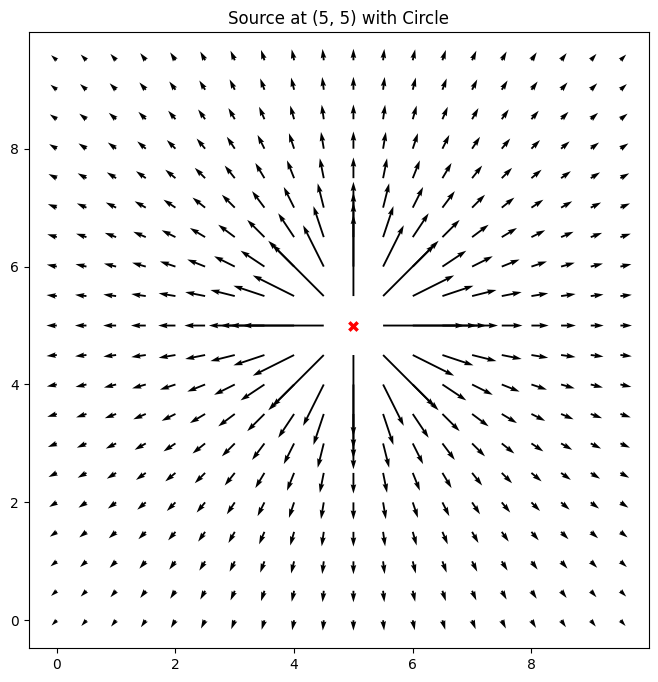

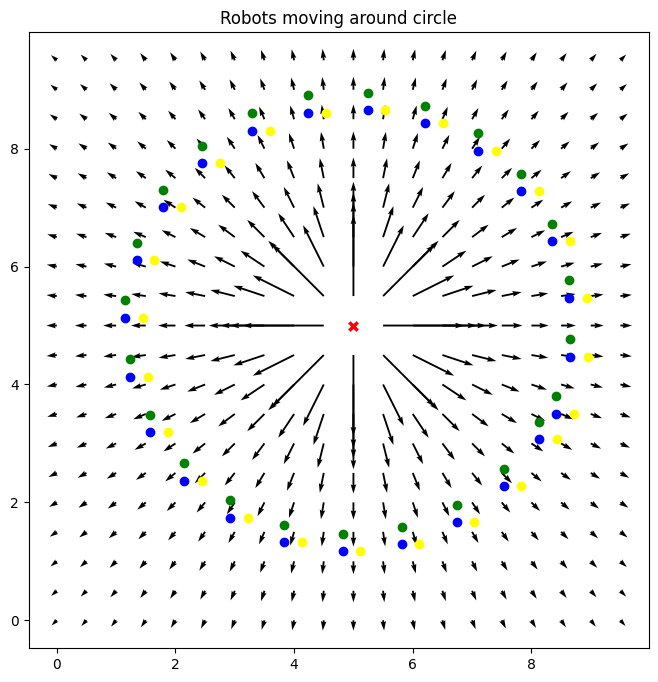

It took this many steps:  24


In [117]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, Eq, solve

# 1. Creating the Environment For Visualization

a= 1.44 # Alternate 
#a = 3.14159/2 # Clockwise
b = -a        # Counter-Clockwise 
rotation = a # Choose a or b

# Create Meshgrid
x = np.arange(0, 10, 0.5)
y = np.arange(0, 10, 0.5)
X, Y = np.meshgrid(x, y)

# Source Location
x_source = 5
y_source = 5

# Centring over source
x_centre = X - x_source
y_centre = Y - y_source

# Radial Distance from Centre
r = np.sqrt(x_centre**2 + y_centre**2)

# Avoid division by zero at the center
r[r==0] = 1e-6

# Calculate the source vectors at each point
u = x_centre / r**2
v = y_centre / r**2

# Create Visualization

plt.figure(figsize=(8,8))
plt.quiver(X,Y,u,v)
plt.scatter(x_source, y_source, color='red', marker='x', linewidths=2.5)
plt.title("Source at (5, 5) with Circle")
plt.show()


plt.figure(figsize=(8,8))
plt.quiver(X,Y,u,v)
plt.scatter(x_source, y_source, color='red', marker='x', linewidths=2.5)


# 2. Initializing the robot positions

x1 = 8.5
y1 = 4
x2 = x1 + 0.3
y2 = y1
x3 = x1
y3 = y1+ 0.3
pos1 = [x1,y1]
pos2 = [x2,y2]
pos3 = [x3,y3]
step_size = 1
steps =0

# 3. Algorithm to move towards source

for _ in range (1,25):
    # Vector Magnitude and Direction at Robot 1
    u_dist1 = pos1[0] - x_source
    v_dist1 = pos1[1] - y_source

    u1 = u_dist1/((u_dist1**2 + v_dist1**2))
    v1 = v_dist1/((u_dist1**2 + v_dist1**2))

    magnitude1 = (u1**2 + v1**2)**0.5
    angle1 = np.arctan2(-v1, -u1)

    # Vector Magnitude and Direction at Robot 2
    u_dist2 = pos2[0] - x_source
    v_dist2 = pos2[1] - y_source

    u2 = u_dist2/((u_dist2**2 + v_dist2**2))
    v2 = v_dist2/((u_dist2**2 + v_dist2**2))

    magnitude2 = (u2**2 + v2**2)**0.5
    angle2 = np.arctan2(-v2, -u2)

    # Vector Magnitude and Direction at Robot 3
    u_dist3 = pos3[0] - x_source
    v_dist3 = pos3[1] - y_source

    u3 = u_dist3/((u_dist3**2 + v_dist3**2))
    v3 = v_dist3/((u_dist3**2 + v_dist3**2))

    magnitude3 = (u3**2 + v3**2)**0.5
    angle3 = np.arctan2(-v3, -u3)

    # Computing Direction fo Source
    angle = (angle1 + angle2 + angle3) / 3 + rotation

    
    # Moving 1 unit in Direction of Source

    pos1[0] += step_size*np.cos(angle)
    pos1[1] += step_size*np.sin(angle)
    pos2[0] += step_size*np.cos(angle)
    pos2[1] += step_size*np.sin(angle)
    pos3[0] += step_size*np.cos(angle)
    pos3[1] += step_size*np.sin(angle)
    steps += 1
    
  
    # Plot each robot
    plt.scatter(pos1[0],pos1[1], marker='o', color='blue')
    plt.scatter(pos2[0],pos2[1], marker='o', color = 'yellow')
    plt.scatter(pos3[0],pos3[1], marker='o', color = 'green')


        
        
# 4. Visualize the output
plt.title("Robots moving around circle")
plt.show()
print('It took this many steps: ', steps)

## Magnitude Follower - Finding Source

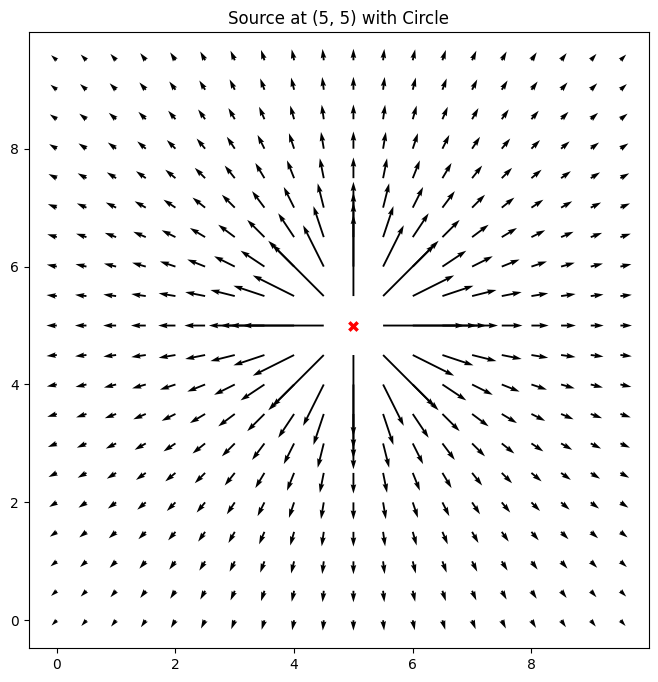

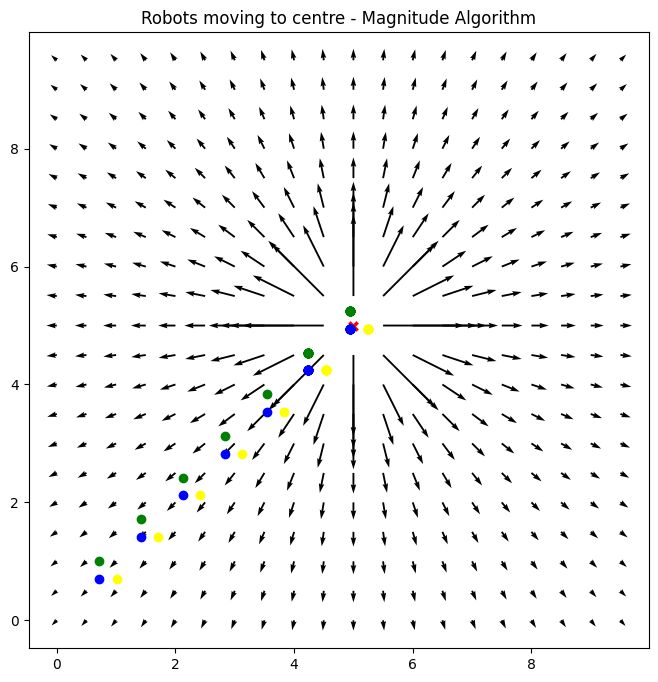

It took this many steps:  49 !  I Cannot think of a kill criteria for this


In [259]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, Eq, solve

# Step 1. Creating the Environment For Visualization

# Create Meshgrid
x = np.arange(0, 10, 0.5)
y = np.arange(0, 10, 0.5)
X, Y = np.meshgrid(x, y)

# Source Location
x_source = 5
y_source = 5

# Centring over source
x_centre = X - x_source
y_centre = Y - y_source

# Radial Distance from Centre
r = np.sqrt(x_centre**2 + y_centre**2)

# Avoid division by zero at the center
r[r==0] = 1e-6

# Calculate the source vectors at each point
u = x_centre / r**2
v = y_centre / r**2

# Create Visualization

plt.figure(figsize=(8,8))
plt.quiver(X,Y,u,v)
plt.scatter(x_source, y_source, color='red', marker='x', linewidths=2.5)
plt.title("Source at (5, 5) with Circle")
plt.show()


## Step 2. Initializing the Robots and Main Algorithm 

# Defining the position of each robot
x1 = 0
y1 = 0
x2 = x1 + 0.3
y2 = y1
x3 = x1
y3 = y1+ 0.3
pos1 = [x1,y1]
pos2 = [x2,y2]
pos3 = [x3,y3]
step_size = 1

# Initializing the Final Plot
steps=0
plt.figure(figsize=(8,8))
plt.quiver(X,Y,u,v)
plt.scatter(x_source, y_source, color='red', marker='x', linewidths=2.5)


## Step 3. Main Algorithm

for _ in range(1,50):

    # Vector Magnitude and Direction at Robot 1
    u_dist1 = pos1[0] - x_source
    v_dist1 = pos1[1] - y_source

    u1 = u_dist1/((u_dist1**2 + v_dist1**2))
    v1 = v_dist1/((u_dist1**2 + v_dist1**2))

    magnitude1 = (u1**2 + v1**2)**0.5
    angle1 = np.arctan2(-v1, -u1)

    # Vector Magnitude and Direction at Robot 2
    u_dist2 = pos2[0] - x_source
    v_dist2 = pos2[1] - y_source

    u2 = u_dist2/((u_dist2**2 + v_dist2**2))
    v2 = v_dist2/((u_dist2**2 + v_dist2**2))

    magnitude2 = (u2**2 + v2**2)**0.5
    angle2 = np.arctan2(-v2, -u2)

    # Vector Magnitude and Direction at Robot 3
    u_dist3 = pos3[0] - x_source
    v_dist3 = pos3[1] - y_source

    u3 = u_dist3/((u_dist3**2 + v_dist3**2))
    v3 = v_dist3/((u_dist3**2 + v_dist3**2))

    magnitude3 = (u3**2 + v3**2)**0.5
    angle3 = np.arctan2(-v3, -u3)

    #Determing Direction
    slope_x = (magnitude2 - magnitude1) / (x2-x1) 
    slope_y = (magnitude3 - magnitude1) / (y3-y1)
    source_direction = np.arctan2(slope_y,slope_x)


    # Moving 1 unit in Direction of Source

    pos1[0] += step_size*np.cos(source_direction)
    pos1[1] += step_size*np.sin(source_direction)
    pos2[0] += step_size*np.cos(source_direction)
    pos2[1] += step_size*np.sin(source_direction)
    pos3[0] += step_size*np.cos(source_direction)
    pos3[1] += step_size*np.sin(source_direction)
    steps += 1


    # Plot each robot
    plt.scatter(pos1[0],pos1[1], marker='o', color='blue')
    plt.scatter(pos2[0],pos2[1], marker='o', color = 'yellow')
    plt.scatter(pos3[0],pos3[1], marker='o', color = 'green')


        
        
# 4. Visualize the output
plt.title("Robots moving to centre - Magnitude Algorithm")
plt.show()
print('It took this many steps: ', steps,'!  I Cannot think of a kill criteria for this')


## Magnitude Follower - Circum-navigate

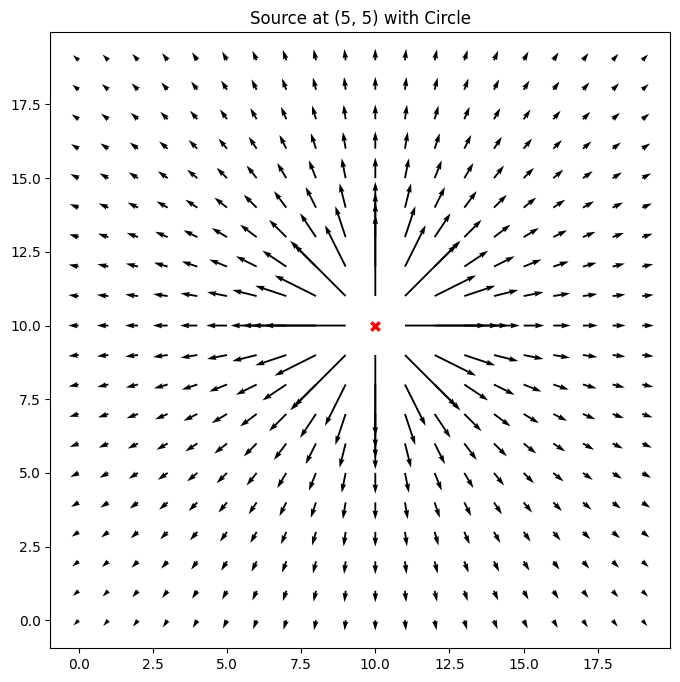

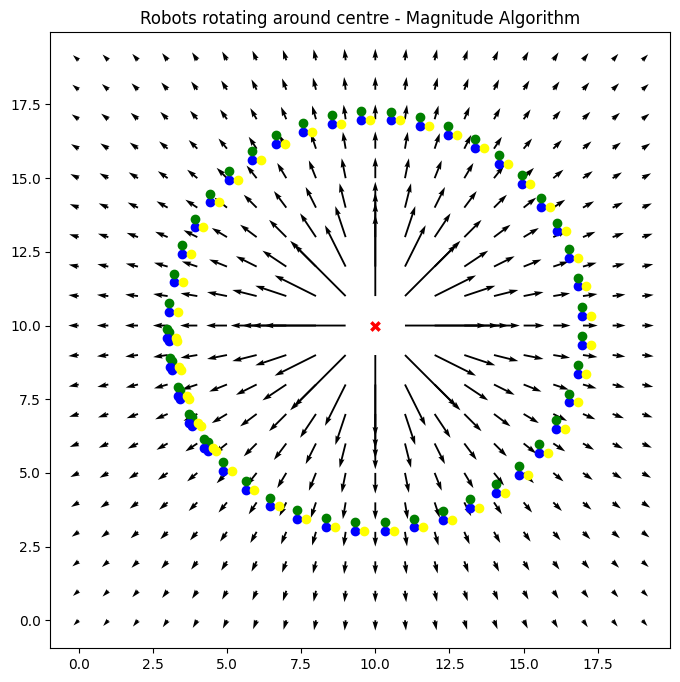

It took this many steps:  98 !  I Cannot think of a kill criteria for this


In [260]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, Eq, solve

# Step 1. Creating the Environment For Visualization

# Create Meshgrid
x = np.arange(0, 20, 1)
y = np.arange(0, 20, 1)
X, Y = np.meshgrid(x, y)

# Source Location
x_source = 10
y_source = 10

# Centring over source
x_centre = X - x_source
y_centre = Y - y_source

# Radial Distance from Centre
r = np.sqrt(x_centre**2 + y_centre**2)

# Avoid division by zero at the center
r[r==0] = 1e-6

# Calculate the source vectors at each point
u = x_centre / r**2
v = y_centre / r**2

# Create Visualization

plt.figure(figsize=(8,8))
plt.quiver(X,Y,u,v)
plt.scatter(x_source, y_source, color='red', marker='x', linewidths=2.5)
plt.title("Source at (5, 5) with Circle")
plt.show()


## Step 2. Initializing the Robots and Main Algorithm 

# Defining the position of each robot
x1 = 5
y1 = 5
x2 = x1 + 0.3
y2 = y1
x3 = x1
y3 = y1+ 0.3
pos1 = [x1,y1]
pos2 = [x2,y2]
pos3 = [x3,y3]
step_size = 1
# Initializing the Final Plot
plt.figure(figsize=(8,8))
plt.quiver(X,Y,u,v)
plt.scatter(x_source, y_source, color='red', marker='x', linewidths=2.5)


## Step 3. Main Algorithm

for _ in range(1,50):

    # Vector Magnitude and Direction at Robot 1
    u_dist1 = pos1[0] - x_source
    v_dist1 = pos1[1] - y_source

    u1 = u_dist1/((u_dist1**2 + v_dist1**2))
    v1 = v_dist1/((u_dist1**2 + v_dist1**2))

    magnitude1 = (u1**2 + v1**2)**0.5
    angle1 = np.arctan2(-v1, -u1)

    # Vector Magnitude and Direction at Robot 2
    u_dist2 = pos2[0] - x_source
    v_dist2 = pos2[1] - y_source

    u2 = u_dist2/((u_dist2**2 + v_dist2**2))
    v2 = v_dist2/((u_dist2**2 + v_dist2**2))

    magnitude2 = (u2**2 + v2**2)**0.5
    angle2 = np.arctan2(-v2, -u2)

    # Vector Magnitude and Direction at Robot 3
    u_dist3 = pos3[0] - x_source
    v_dist3 = pos3[1] - y_source

    u3 = u_dist3/((u_dist3**2 + v_dist3**2))
    v3 = v_dist3/((u_dist3**2 + v_dist3**2))

    magnitude3 = (u3**2 + v3**2)**0.5
    angle3 = np.arctan2(-v3, -u3) 

    #Determing Direction
    slope_x = (magnitude2 - magnitude1) / (x2-x1) 
    slope_y = (magnitude3 - magnitude1) / (y3-y1)
    source_direction = np.arctan2(slope_y,slope_x) + 1.5


    # Moving 1 unit in Direction of Source

    pos1[0] += step_size*np.cos(source_direction)
    pos1[1] += step_size*np.sin(source_direction)
    pos2[0] += step_size*np.cos(source_direction)
    pos2[1] += step_size*np.sin(source_direction)
    pos3[0] += step_size*np.cos(source_direction)
    pos3[1] += step_size*np.sin(source_direction)
    steps += 1


    # Plot each robot
    plt.scatter(pos1[0],pos1[1], marker='o', color='blue')
    plt.scatter(pos2[0],pos2[1], marker='o', color = 'yellow')
    plt.scatter(pos3[0],pos3[1], marker='o', color = 'green')


        
        
# 4. Visualize the output
plt.title("Robots rotating around centre - Magnitude Algorithm")
plt.show()
print('It took this many steps: ', steps,'!  I Cannot think of a kill criteria for this')


## Source Finder Algorithm - New

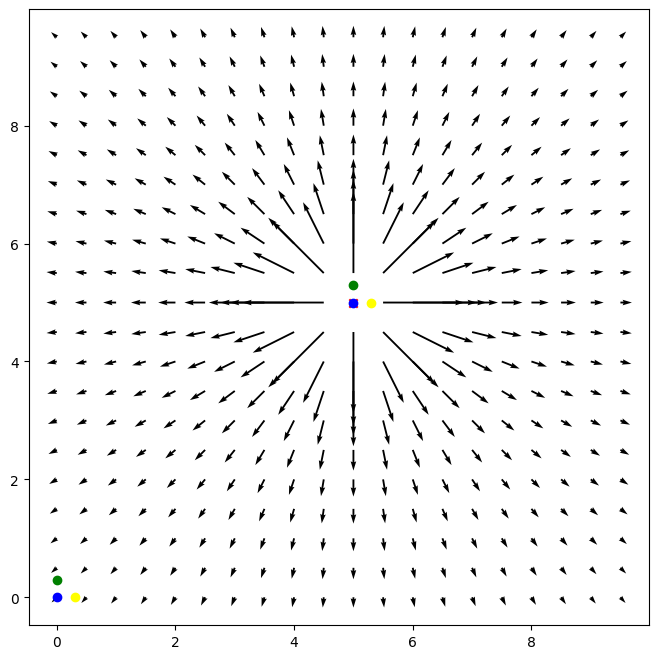

Estimated source position:  [5.00000000000000, 5.00000000000000]


In [261]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, Eq, solve

# Step 1. Creating the Environment For Visualization

# Create Meshgrid
x = np.arange(0, 10, 0.5)
y = np.arange(0, 10, 0.5)
X, Y = np.meshgrid(x, y)

# Source Location
x_source = 5
y_source = 5

# Centring over source
x_centre = X - x_source
y_centre = Y - y_source

# Radial Distance from Centre
r = np.sqrt(x_centre**2 + y_centre**2)

# Avoid division by zero at the center
r[r==0] = 1e-6

# Calculate the source vectors at each point
u = x_centre / r**2
v = y_centre / r**2

# Step 2. Defining Fxns

def find_source(pos1, angle1, pos2, angle2, pos3, angle3):
    # Set up symbols
    x, y = symbols('x y')


    # Form equations of lines from angles and positions, angle is with respect to upward direction
    eq1 = Eq((y - pos1[1]) - np.tan(angle1)*(x - pos1[0]), 0)
    eq2 = Eq((y - pos2[1]) - np.tan(angle2)*(x - pos2[0]), 0)
    eq3 = Eq((y - pos3[1]) - np.tan(angle3)*(x - pos3[0]), 0)

    solution12 = solve((eq1,eq2), (x, y))
    solution23 = solve((eq2,eq3), (x, y))
    solution13 = solve((eq1,eq3), (x, y))

    # Average of intersection points
    avg_x = (solution12[x] + solution23[x] + solution13[x]) / 3
    avg_y = (solution12[y] + solution23[y] + solution13[y]) / 3
    
    source_location = [avg_x, avg_y]

    return source_location


## Step 3. Initializing the Main Algorithm.

# Initializing Robot Pose
x1 = 0
y1 = 0
x2 = x1 + 0.3
y2 = y1
x3 = x1
y3 = y1+ 0.3
pos1 = [x1,y1]
pos2 = [x2,y2]
pos3 = [x3,y3]

#  Intro Plot
plt.figure(figsize=(8,8))
plt.quiver(X,Y,u,v)
plt.scatter(x_source,y_source,marker='x',color='red')
plt.scatter(pos1[0],pos1[1], marker='o', color='blue')
plt.scatter(pos2[0],pos2[1], marker='o', color = 'yellow')
plt.scatter(pos3[0],pos3[1], marker='o', color = 'green')

##  Step 4. Main Algorithm - Only involves 1 step

# Vector Magnitude and Direction at Robot 1
u_dist1 = pos1[0] - x_source
v_dist1 = pos1[1] - y_source
u1 = u_dist1/((u_dist1**2 + v_dist1**2))
v1 = v_dist1/((u_dist1**2 + v_dist1**2))
magnitude1 = (u1**2 + v1**2)**0.5
angle1 = np.arctan2(-v1, -u1)

# Vector Magnitude and Direction at Robot 2
u_dist2 = pos2[0] - x_source
v_dist2 = pos2[1] - y_source
u2 = u_dist2/((u_dist2**2 + v_dist2**2))
v2 = v_dist2/((u_dist2**2 + v_dist2**2))
magnitude2 = (u2**2 + v2**2)**0.5
angle2 = np.arctan2(-v2, -u2)

# Vector Magnitude and Direction at Robot 3
u_dist3 = pos3[0] - x_source
v_dist3 = pos3[1] - y_source
u3 = u_dist3/((u_dist3**2 + v_dist3**2))
v3 = v_dist3/((u_dist3**2 + v_dist3**2))
magnitude3 = (u3**2 + v3**2)**0.5
angle3 = np.arctan2(-v3, -u3) 

# Determining Where the Source is
source_location = find_source(pos1, angle1, pos2, angle2, pos3, angle3)

# Updating the Robot Position

pos1[0] = source_location[0]
pos1[1] = source_location[1]
pos2[0] = pos1[0] + 0.3
pos2[1] = pos1[0]
pos3[0] = pos1[0]
pos3[1] = pos1[0] + 0.3

#Plotting the Final Location of the robots

plt.scatter(pos1[0],pos1[1], marker='o', color='blue')
plt.scatter(pos2[0],pos2[1], marker='o', color = 'yellow')
plt.scatter(pos3[0],pos3[1], marker='o', color = 'green')
plt.show()
    
    
print('Estimated source position: ', source_location)


## Source Circumnavigator - New

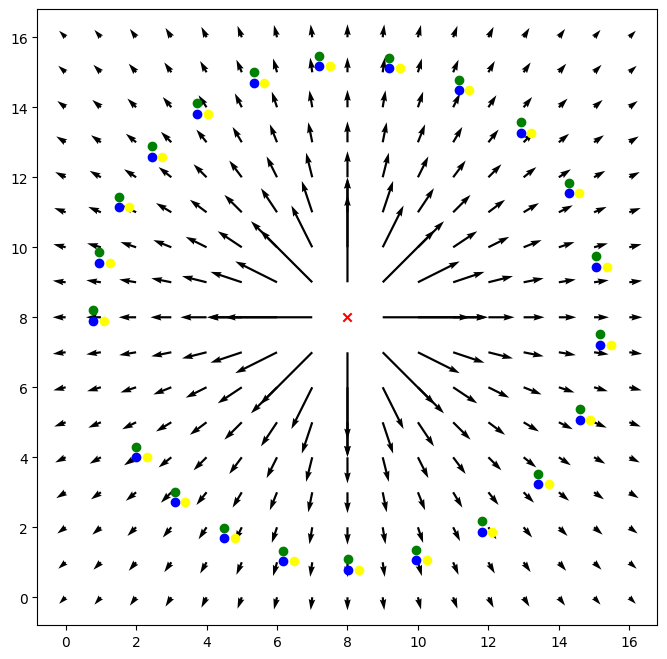

Estimated source position:  [7.999999999999388, 8.000000000000137]


In [256]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, Eq, solve

# Step 1. Creating the Environment For Visualization

# Create Meshgrid
x = np.arange(0, 17, 1)
y = np.arange(0, 17, 1)
X, Y = np.meshgrid(x, y)

# Source Location
x_source = 8
y_source = 8

# Centring over source
x_centre = X - x_source
y_centre = Y - y_source

# Radial Distance from Centre
r = np.sqrt(x_centre**2 + y_centre**2)

# Avoid division by zero at the center
r[r==0] = 1e-6

# Calculate the source vectors at each point
u = x_centre / r**2
v = y_centre / r**2

# Step 2. Defining Fxns

def find_source(pos1, angle1, pos2, angle2, pos3, angle3):
    # Set up symbols
    x, y = symbols('x y')


    # Form equations of lines from angles and positions, angle is with respect to upward direction
    eq1 = Eq((y - pos1[1]) - np.tan(angle1)*(x - pos1[0]), 0)
    eq2 = Eq((y - pos2[1]) - np.tan(angle2)*(x - pos2[0]), 0)
    eq3 = Eq((y - pos3[1]) - np.tan(angle3)*(x - pos3[0]), 0)

    solution12 = solve((eq1,eq2), (x, y))
    solution23 = solve((eq2,eq3), (x, y))
    solution13 = solve((eq1,eq3), (x, y))


  
    # Average of intersection points
    avg_x = (solution12[x] + solution23[x] + solution13[x]) / 3
    avg_y = (solution12[y] + solution23[y] + solution13[y]) / 3
    avg_x = float(avg_x.evalf())
    avg_y = float(avg_y.evalf())
    
    source_location = [avg_x, avg_y]

    return source_location


## Step 3. Initializing the Main Algorithm.

# Initializing Robot Pose and Step Size
x1 = 2
y1 = 4
x2 = x1 + 0.3
y2 = y1
x3 = x1
y3 = y1+ 0.3
pos1 = [x1,y1]
pos2 = [x2,y2]
pos3 = [x3,y3]
step_size = 2

#  Intro Plot
plt.figure(figsize=(8,8))
plt.quiver(X,Y,u,v)
plt.scatter(x_source,y_source,marker='x',color='red')
plt.scatter(pos1[0],pos1[1], marker='o', color='blue')
plt.scatter(pos2[0],pos2[1], marker='o', color = 'yellow')
plt.scatter(pos3[0],pos3[1], marker='o', color = 'green')

##  Step 4. Main Algorithm - Rotates around

for _ in range (1,22):

    # Vector Magnitude and Direction at Robot 1
    u_dist1 = pos1[0] - x_source
    v_dist1 = pos1[1] - y_source
    u1 = u_dist1/((u_dist1**2 + v_dist1**2))
    v1 = v_dist1/((u_dist1**2 + v_dist1**2))
    magnitude1 = (u1**2 + v1**2)**0.5
    angle1 = np.arctan2(-v1, -u1)

    # Vector Magnitude and Direction at Robot 2
    u_dist2 = pos2[0] - x_source
    v_dist2 = pos2[1] - y_source
    u2 = u_dist2/((u_dist2**2 + v_dist2**2))
    v2 = v_dist2/((u_dist2**2 + v_dist2**2))
    magnitude2 = (u2**2 + v2**2)**0.5
    angle2 = np.arctan2(-v2, -u2)

    # Vector Magnitude and Direction at Robot 3
    u_dist3 = pos3[0] - x_source
    v_dist3 = pos3[1] - y_source
    u3 = u_dist3/((u_dist3**2 + v_dist3**2))
    v3 = v_dist3/((u_dist3**2 + v_dist3**2))
    magnitude3 = (u3**2 + v3**2)**0.5
    angle3 = np.arctan2(-v3, -u3) 

    # Determining Where the Source is
    source_location = find_source(pos1, angle1, pos2, angle2, pos3, angle3)

    # Determine angle and distance relative to source
    current_angle = np.arctan2(v3,u3)
    current_mag = np.sqrt((pos1[0]-source_location[0])**2 + (pos1[1]-source_location[1])**2)

    # Calculate Angle Needed to move
    move_angle = np.arctan2(step_size, current_mag)
    new_angle = current_angle + move_angle

    # Calculate new posistion

    pos1[0] = source_location[0] + current_mag*np.cos(new_angle)
    pos1[1] = source_location[1] + current_mag*np.sin(new_angle)
    pos2[0] = pos1[0] + 0.3
    pos2[1] = pos1[1]
    pos3[0] = pos1[0]
    pos3[1] = pos1[1]+ 0.3

    #Plotting the Final Location of the robots

    plt.scatter(pos1[0],pos1[1], marker='o', color='blue')
    plt.scatter(pos2[0],pos2[1], marker='o', color = 'yellow')
    plt.scatter(pos3[0],pos3[1], marker='o', color = 'green')

plt.show()
    
    
print('Estimated source position: ', source_location)
